In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
import skops
import skops.io as sio

import json
import os
import sys
import warnings
warnings.filterwarnings('ignore')

drug_df = pd.read_csv('data/drug.csv').sample(frac=1)

drug_df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
172,39,F,NORMAL,NORMAL,17.225,DrugY
189,64,M,HIGH,NORMAL,20.932,DrugY
10,47,F,LOW,HIGH,11.767,drugC
82,32,F,LOW,HIGH,9.712,drugC
39,15,M,NORMAL,HIGH,9.084,drugX


In [ ]:
X = drug_df.drop('Drug', axis=1)
y = drug_df['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.head())
print(y_train.head())

     Age Sex      BP Cholesterol  Na_to_K
131   52   M     LOW      NORMAL   32.922
160   30   F  NORMAL        HIGH   10.443
35    46   M  NORMAL      NORMAL    7.285
118   32   F    HIGH      NORMAL   10.292
187   47   M    HIGH        HIGH   10.403
131    DrugY
160    drugX
35     drugX
118    drugA
187    drugA
Name: Drug, dtype: str


Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

Accuracy: 1.0
              precision    recall  f1-score   support

       DrugY       1.00      1.00      1.00        22
       drugA       1.00      1.00      1.00         3
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      1.00      1.00         9

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



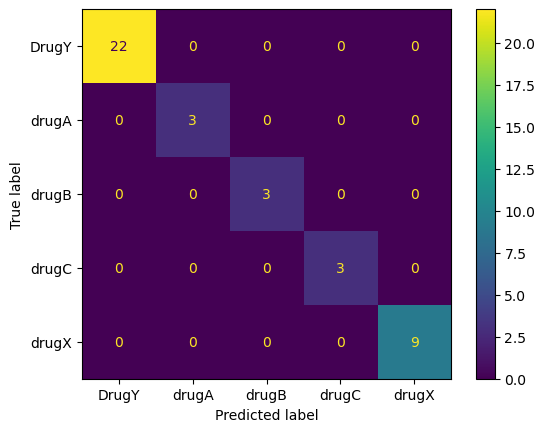

<Figure size 640x480 with 0 Axes>

In [9]:
from sklearn.compose import ColumnTransformer    # different transformations for different columns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

cat_cols = ['Sex']
ord_cols = ['BP', 'Cholesterol']
num_cols = ['Age', 'Na_to_K']

transform = ColumnTransformer(
    [
        (
            'ord_enc',
            OrdinalEncoder(categories=[
                ['LOW', 'NORMAL', 'HIGH'],   # BP
                ['NORMAL', 'HIGH'],          # Cholesterol
            ]),
            ord_cols,
        ),
        (
            'cat_enc',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols,
        ),
        (
            'num',
            # ColumnTransformer steps run in parallel on the original columns, not in
            # sequence. Separate imputer + scaler entries (as in the tutorial) would
            # output duplicate numeric columns (imputed unscaled + scaled originals) and
            # would not scale the imputed values. A nested Pipeline imputes first, then
            # scales that output — the correct order when both steps are needed.
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            num_cols,
        ),
    ],
)

pipe = Pipeline([
    ('preprocessing', transform),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42)),
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


with open("results/metrics.json", "w") as f:
    json.dump({"accuracy": accuracy_score(y_test, y_pred)}, f)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()
plt.show()
plt.savefig("results/confusion_matrix.png")



Input columns: 2 ['Age', 'Na_to_K']
Tutorial output shape: (160, 4)
Correct output shape: (160, 2)

Tutorial feature names:
['num_imputer__Age' 'num_imputer__Na_to_K' 'num_scaler__Age'
 'num_scaler__Na_to_K']

First row — tutorial (imputed unscaled + scaled originals):
[52.         32.922       0.44485792  2.27853788]

First row — correct (imputed then scaled):
[0.44485792 2.27853788]
